# Data Scraping

This notebook contains code to scrap data on weather, UK bank holidays and covid times etc. The notebook also formats the data before modelling.

Different datasets need to be collected, cleaned and joined:

Variable | Unit | Description | Source
---------|------|----------|----------
Estimated Actual Footfall | | Number of visitors in area for a given day. | [HUQ](https://huq.io/insights/footfall-data/)
Cos_weekday_num| |Cosine of the week day number | 
Sin_weekday_num| |Sinus of the week day number | 
Cos_month_num| |  Cosine of the month number| 
Sin_month_num| | Sinus of the month number| 
Cos_week_of_year| | Cosine of the week of year number| 
Sin_week_of_year| | Sinus of the week of year number | 
Year| | | 
bank_hol| |Whether or not that day is a bank holiday (0= No, 1= Yes)|[Kaggle](https://www.kaggle.com/datasets/shivd24coder/uk-national-holidays-dataset)
school_hol| |Whether or not that day is a school holiday (0= No, 1= Yes)|[Bradford Council](https://bradford.gov.uk/)
Covid times| |Whether or not that day was during covid restrictions (0= No, 1= Yes)|
Precipitation | mm | Sum of daily precipitation (including rain, showers and snowfall) | [Open Meteo API](https://open-meteo.com/en/docs/historical-weather-api?bounding_box=-90,-180,90,180&hourly=&daily=temperature_2m_mean,precipitation_sum,wind_speed_10m_max)
Temperature | °C | Average daily air temperature at 2 meters above ground | [Open Meteo API](https://open-meteo.com/en/docs/historical-weather-api?bounding_box=-90,-180,90,180&hourly=&daily=temperature_2m_mean,precipitation_sum,wind_speed_10m_max)
Wind Speed | km/h | Maximum wind speed on a day | [Open Meteo API](https://open-meteo.com/en/docs/historical-weather-api?bounding_box=-90,-180,90,180&hourly=&daily=temperature_2m_mean,precipitation_sum,wind_speed_10m_max)
Daylight Duration | seconds | Number of seconds of daylight per day | [Open Meteo API](https://open-meteo.com/en/docs/historical-weather-api?bounding_box=-90,-180,90,180&hourly=&daily=temperature_2m_mean,precipitation_sum,wind_speed_10m_max)

In [1]:
pip install matplotlib geopandas numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import geopandas as gpd
import numpy as np

In [3]:
#Load footfall data
footfall = pd.read_csv(r"c:\Users\qxnq723\Desktop\Project 1\Coding\Analysis - Bradford District MetOffice\Bradford Analysis- RFR No lag-roll\footfall_MetOf_Clean")
footfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2470 entries, 0 to 2469
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         2470 non-null   int64  
 1   datestamp                          2470 non-null   object 
 2   estimated_actual_footfall          2306 non-null   float64
 3   estimated_actual_footfall_rolling  2470 non-null   int64  
 4   year                               2470 non-null   int64  
 5   month                              2470 non-null   int64  
 6   monthday                           2470 non-null   int64  
 7   weekday                            2470 non-null   int64  
 8   week_of_year                       2470 non-null   int64  
 9   Sin_weekday                        2470 non-null   float64
 10  Cos_weekday                        2470 non-null   float64
 11  Sin_monthday                       2470 non-null   float

In [4]:
#Convert datestamp to datetime
footfall['datestamp'] = pd.to_datetime(footfall['datestamp'])

## Weekends

In [5]:
#Create binary on whether day is a Saturday or Sunday
weekend = {5, 6}
#Add column in footfall data (1= weekend, 0= normal day)
footfall['is_weekend'] = footfall['weekday'].isin(weekend).astype(int)
#Check
footfall.head()

,Unnamed: 0,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,...,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,date_str,week_monday,week_index,is_weekend
0,0,2019-01-01,530996.0,571980,2019,1,1,1,1,8.660254e-01,...,0.201299,0.979530,0.118273,0.992981,0.5,0.866025,2019-01-01,2018-12-31,2018-12-31,0
1,1,2019-01-02,568621.0,572734,2019,1,2,2,1,8.660254e-01,...,0.394356,0.918958,0.118273,0.992981,0.5,0.866025,2019-01-02,2018-12-31,2018-12-31,0
2,2,2019-01-03,606939.0,538667,2019,1,3,3,1,1.224647e-16,...,0.571268,0.820763,0.118273,0.992981,0.5,0.866025,2019-01-03,2018-12-31,2018-12-31,0
3,3,2019-01-04,508695.0,532787,2019,1,4,4,1,-8.660254e-01,...,0.724793,0.688967,0.118273,0.992981,0.5,0.866025,2019-01-04,2018-12-31,2018-12-31,0
4,4,2019-01-05,468546.0,507700,2019,1,5,5,1,-8.660254e-01,...,0.848644,0.528964,0.118273,0.992981,0.5,0.866025,2019-01-05,2018-12-31,2018-12-31,1


## Bank Holidays
Bank holiday data was collected from Kaggle.

In [6]:
bank_hols = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Bradford Data\UK_holiday.csv")
bank_hols.head()

,title,date,notes,bunting
0,New Year’s Day,2018-01-01,NaN,True
1,Good Friday,2018-03-30,NaN,False
2,Easter Monday,2018-04-02,NaN,True
3,Early May bank holiday,2018-05-07,NaN,True
4,Spring bank holiday,2018-05-28,NaN,True


In [7]:
#Check date range
bank_hols['date'].unique()

array(['2018-01-01', '2018-03-30', '2018-04-02', '2018-05-07',
       '2018-05-28', '2018-08-27', '2018-12-25', '2018-12-26',
       '2019-01-01', '2019-04-19', '2019-04-22', '2019-05-06',
       '2019-05-27', '2019-08-26', '2019-12-25', '2019-12-26',
       '2020-01-01', '2020-04-10', '2020-04-13', '2020-05-08',
       '2020-05-25', '2020-08-31', '2020-12-25', '2020-12-28',
       '2021-01-01', '2021-04-02', '2021-04-05', '2021-05-03',
       '2021-05-31', '2021-08-30', '2021-12-27', '2021-12-28',
       '2022-01-03', '2022-04-15', '2022-04-18', '2022-05-02',
       '2022-06-02', '2022-06-03', '2022-08-29', '2022-09-19',
       '2022-12-26', '2022-12-27', '2023-01-02', '2023-04-07',
       '2023-04-10', '2023-05-01', '2023-05-08', '2023-05-29',
       '2023-08-28', '2023-12-25', '2023-12-26', '2024-01-01',
       '2024-03-29', '2024-04-01', '2024-05-06', '2024-05-27',
       '2024-08-26', '2024-12-25', '2024-12-26', '2025-01-01',
       '2025-04-18', '2025-04-21', '2025-05-05', '2025-

The data includes all bank holidays between 2019 and 2025, thus we can create a variable in the footfall data to indicate whether or not a day falls on a bank holiday, using the one hot encoding technique (0 is no, 1 is yes).

In [8]:
#Convert datestamp to datetime
bank_hols['date'] = pd.to_datetime(bank_hols['date'])
#Create set of bank holiday dates
holiday_set = set(bank_hols['date'])

In [9]:
#Add column in footfall data (1= holiday, 0= normal day)
footfall['bank_hol'] = footfall['datestamp'].isin(holiday_set).astype(int)
#Check
footfall.head()

,Unnamed: 0,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,...,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,date_str,week_monday,week_index,is_weekend,bank_hol
0,0,2019-01-01,530996.0,571980,2019,1,1,1,1,8.660254e-01,...,0.979530,0.118273,0.992981,0.5,0.866025,2019-01-01,2018-12-31,2018-12-31,0,1
1,1,2019-01-02,568621.0,572734,2019,1,2,2,1,8.660254e-01,...,0.918958,0.118273,0.992981,0.5,0.866025,2019-01-02,2018-12-31,2018-12-31,0,0
2,2,2019-01-03,606939.0,538667,2019,1,3,3,1,1.224647e-16,...,0.820763,0.118273,0.992981,0.5,0.866025,2019-01-03,2018-12-31,2018-12-31,0,0
3,3,2019-01-04,508695.0,532787,2019,1,4,4,1,-8.660254e-01,...,0.688967,0.118273,0.992981,0.5,0.866025,2019-01-04,2018-12-31,2018-12-31,0,0
4,4,2019-01-05,468546.0,507700,2019,1,5,5,1,-8.660254e-01,...,0.528964,0.118273,0.992981,0.5,0.866025,2019-01-05,2018-12-31,2018-12-31,1,0


## School Holidays
Data regarding the school holidays was manually scraped from calendars provided on the 'City of Bradford Metropolitan District Council' website. Thus, dates that fall within this school holiday periods will be assigned a 1 in the 'school_holiday' column.

In [10]:
#Create set of dates which were school holidays

school_hols_periods = [
    ('2019-01-01', '2019-01-04'),
    ('2019-02-18', '2019-02-22'),
    ('2019-04-15', '2019-04-26'),
    ('2019-05-27', '2019-05-31'),
    ('2019-07-22', '2019-07-31'),
    ('2019-08-01', '2019-08-31'),
    ('2019-10-28', '2019-10-30'),
    ('2019-05-27', '2019-05-31'),
    ('2019-12-23', '2019-12-31'),
    ('2020-01-01', '2020-01-03'),
    ('2020-02-17', '2020-02-19'),
    ('2020-04-06', '2020-04-17'),
    ('2020-05-25', '2020-05-29'),
    ('2020-07-21', '2020-09-02'),
    ('2020-10-26', '2020-10-28'),
    ('2020-12-21', '2021-01-01'),
    ('2021-02-15', '2021-02-17'),
    ('2021-03-29', '2021-04-09'),
    ('2021-06-01', '2021-06-04'),
    ('2021-07-26', '2021-09-03'),
    ('2021-10-25', '2021-10-27'),
    ('2021-12-20', '2022-01-03'),
    ('2022-02-21', '2022-02-23'),
    ('2022-04-11', '2022-04-22'),
    ('2022-05-31', '2022-06-03'),
    ('2022-07-27', '2022-09-02'),
    ('2022-10-24', '2022-10-26'),
    ('2022-12-19', '2023-01-02'),
    ('2023-02-13', '2023-02-15'),
    ('2023-04-03', '2023-04-14'),
    ('2023-05-29', '2023-06-02'),
    ('2023-07-26', '2023-09-01'),
    ('2023-10-23', '2023-10-25'),
    ('2023-12-18', '2024-01-01'),
    ('2024-02-12', '2024-02-14'),
    ('2024-03-25', '2024-04-05'),
    ('2024-05-27', '2024-05-31'),
    ('2024-07-24', '2024-08-30'),
    ('2024-10-28', '2024-11-01'),
    ('2024-12-23', '2025-01-03'),
    ('2025-02-17', '2025-02-21'),
    ('2025-04-07', '2025-04-18'),
    ('2025-05-26', '2025-05-30'),
    ('2025-07-23', '2025-08-29'),
    ('2025-10-27', '2025-10-31'),
    ('2025-12-22', '2026-01-02'),
]

school_hols_dates = pd.DatetimeIndex([])
for start, end in school_hols_periods:
    school_hols_dates = school_hols_dates.union(
        pd.date_range(start=start, end=end, freq='D'))
    
#Check
school_hols_dates

DatetimeIndex(['2019-01-01', '2019-01-02', '2019-01-03', '2019-01-04',
               '2019-02-18', '2019-02-19', '2019-02-20', '2019-02-21',
               '2019-02-22', '2019-04-15',
               ...
               '2025-12-24', '2025-12-25', '2025-12-26', '2025-12-27',
               '2025-12-28', '2025-12-29', '2025-12-30', '2025-12-31',
               '2026-01-01', '2026-01-02'],
              dtype='datetime64[ns]', length=541, freq=None)

In [11]:
#Add column in footfall data (1= covid, 0= normal day)
footfall['school_hol'] = footfall['datestamp'].isin(school_hols_dates).astype(int)
#Check
footfall.head()

,Unnamed: 0,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,...,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,date_str,week_monday,week_index,is_weekend,bank_hol,school_hol
0,0,2019-01-01,530996.0,571980,2019,1,1,1,1,8.660254e-01,...,0.118273,0.992981,0.5,0.866025,2019-01-01,2018-12-31,2018-12-31,0,1,1
1,1,2019-01-02,568621.0,572734,2019,1,2,2,1,8.660254e-01,...,0.118273,0.992981,0.5,0.866025,2019-01-02,2018-12-31,2018-12-31,0,0,1
2,2,2019-01-03,606939.0,538667,2019,1,3,3,1,1.224647e-16,...,0.118273,0.992981,0.5,0.866025,2019-01-03,2018-12-31,2018-12-31,0,0,1
3,3,2019-01-04,508695.0,532787,2019,1,4,4,1,-8.660254e-01,...,0.118273,0.992981,0.5,0.866025,2019-01-04,2018-12-31,2018-12-31,0,0,1
4,4,2019-01-05,468546.0,507700,2019,1,5,5,1,-8.660254e-01,...,0.118273,0.992981,0.5,0.866025,2019-01-05,2018-12-31,2018-12-31,1,0,0


## Covid
The first covid lock down occured on the 23rd of March 2020 and the last covid restrictions were lifted on the 24 February 2022 in England. Thus, dates that fall within this period will be assigned a 1 in the 'covid' column.

In [12]:
#Create set of dates during covid times in UK
start= '2020-03-23'
end= '2022-02-24'

covid_dates = pd.date_range(start=start, end=end, freq='D')

#Add column in footfall data (1= covid, 0= normal day)
footfall['covid'] = footfall['datestamp'].isin(covid_dates).astype(int)
#Check
footfall.head()

,Unnamed: 0,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,...,Cos_week_of_year,Sin_month,Cos_month,date_str,week_monday,week_index,is_weekend,bank_hol,school_hol,covid
0,0,2019-01-01,530996.0,571980,2019,1,1,1,1,8.660254e-01,...,0.992981,0.5,0.866025,2019-01-01,2018-12-31,2018-12-31,0,1,1,0
1,1,2019-01-02,568621.0,572734,2019,1,2,2,1,8.660254e-01,...,0.992981,0.5,0.866025,2019-01-02,2018-12-31,2018-12-31,0,0,1,0
2,2,2019-01-03,606939.0,538667,2019,1,3,3,1,1.224647e-16,...,0.992981,0.5,0.866025,2019-01-03,2018-12-31,2018-12-31,0,0,1,0
3,3,2019-01-04,508695.0,532787,2019,1,4,4,1,-8.660254e-01,...,0.992981,0.5,0.866025,2019-01-04,2018-12-31,2018-12-31,0,0,1,0
4,4,2019-01-05,468546.0,507700,2019,1,5,5,1,-8.660254e-01,...,0.992981,0.5,0.866025,2019-01-05,2018-12-31,2018-12-31,1,0,0,0


## Weather

This section collects daily weather data (average temperature, total precipitation, maximum wind speed) for Bradford over the study period (2019-2025) using the Open Meteo API.

In [13]:
pip install --update typing extensions

Note: you may need to restart the kernel to use updated packages.



Usage:   
  c:\ProgramData\anaconda3\envs\timeseries\python.exe -m pip install [options] <requirement specifier> [package-index-options] ...
  c:\ProgramData\anaconda3\envs\timeseries\python.exe -m pip install [options] -r <requirements file> [package-index-options] ...
  c:\ProgramData\anaconda3\envs\timeseries\python.exe -m pip install [options] [-e] <vcs project url> ...
  c:\ProgramData\anaconda3\envs\timeseries\python.exe -m pip install [options] [-e] <local project path> ...
  c:\ProgramData\anaconda3\envs\timeseries\python.exe -m pip install [options] <archive url/path> ...

no such option: --update


In [14]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests

  Using cached openmeteo_requests-1.7.4-py3-none-any.whl.metadata (11 kB)
  Using cached openmeteo_sdk-1.23.0-py3-none-any.whl.metadata (935 bytes)
  Using cached jh2-5.0.10-cp37-abi3-win_amd64.whl.metadata (4.1 kB)
  Using cached qh3-1.5.6-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl.metadata (875 bytes)
Using cached openmeteo_requests-1.7.4-py3-none-any.whl (7.0 kB)
   ---------------------------------------- 0.0/684.7 kB ? eta -:--:--
   ---------------------------------------- 684.7/684.7 kB 9.0 MB/s  0:00:00
Using cached jh2-5.0.10-cp37-abi3-win_amd64.whl (246 kB)
Using cached qh3-1.5.6-cp37-abi3-win_amd64.whl (2.0 MB)
Using cached openmeteo_sdk-1.23.0-py3-none-any.whl (18 kB)
Using cached flatbuffers-25.9.23-py2.py3-none-any.whl (30 kB)

   ---------------------------------------- 0/8 [flatbuffers]
   ---------------------------------------- 0/8 [flatbuffers]
   ---------------------------------------- 0/8 [flatbuffers]
   ----

In [15]:
#Import packages
import openmeteo_requests
import requests_cache
from retry_requests import retry

In [16]:
#Code provided by Open-Meteo API website

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 53.799999,
	"longitude": -1.750000,
	"start_date": "2019-01-01",
	"end_date": "2025-12-01",
	"daily": ["temperature_2m_mean", "precipitation_sum", "wind_speed_10m_max", "daylight_duration"],
}

responses = openmeteo.weather_api(url, params=params)

# Process location
response = responses[0]


# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(1).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(2).ValuesAsNumpy()
daily_daylight_duration = daily.Variables(3).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["daylight_duration"] = daily_daylight_duration

daily_weather = pd.DataFrame(data = daily_data)
print("\nDaily data\n", daily_weather)


Daily data
                           date  temperature_2m_mean  precipitation_sum  \
0    2019-01-01 00:00:00+00:00             6.158333           0.000000   
1    2019-01-02 00:00:00+00:00             2.304167           0.000000   
2    2019-01-03 00:00:00+00:00             0.387500           0.000000   
3    2019-01-04 00:00:00+00:00             2.064583           0.000000   
4    2019-01-05 00:00:00+00:00             3.768750           0.000000   
...                        ...                  ...                ...   
2522 2025-11-27 00:00:00+00:00            11.193751           1.700000   
2523 2025-11-28 00:00:00+00:00             7.647917           4.600000   
2524 2025-11-29 00:00:00+00:00             4.614583           9.000000   
2525 2025-11-30 00:00:00+00:00             3.191667           0.500000   
2526 2025-12-01 00:00:00+00:00             9.541667          16.900002   

      wind_speed_10m_max  daylight_duration  
0              24.490587       27067.837891  
1     

In [17]:
#Rename column
daily_weather= daily_weather.rename(columns= {'date': 'datestamp'})

#Convert datestamp (avoids having hour:min:secs) to timezone naive
daily_weather['datestamp'] = (pd.to_datetime(daily_weather['datestamp'])
                              .dt.tz_localize(None)
                              .dt.normalize())

In [18]:
daily_weather.head()

,datestamp,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration
0,2019-01-01,6.158333,0.0,24.490587,27067.837891
1,2019-01-02,2.304167,0.0,10.086427,27147.843750
2,2019-01-03,0.387500,0.0,6.480000,27235.123047
3,2019-01-04,2.064583,0.0,15.629971,27329.416016
4,2019-01-05,3.768750,0.0,14.168641,27430.486328


In [19]:
#Merge the weather data and the footfall data based on dates
footfall_clean = footfall.merge(daily_weather[['datestamp', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'daylight_duration']], on='datestamp')
footfall_clean.head()

,Unnamed: 0,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,...,week_monday,week_index,is_weekend,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration
0,0,2019-01-01,530996.0,571980,2019,1,1,1,1,8.660254e-01,...,2018-12-31,2018-12-31,0,1,1,0,6.158333,0.0,24.490587,27067.837891
1,1,2019-01-02,568621.0,572734,2019,1,2,2,1,8.660254e-01,...,2018-12-31,2018-12-31,0,0,1,0,2.304167,0.0,10.086427,27147.843750
2,2,2019-01-03,606939.0,538667,2019,1,3,3,1,1.224647e-16,...,2018-12-31,2018-12-31,0,0,1,0,0.387500,0.0,6.480000,27235.123047
3,3,2019-01-04,508695.0,532787,2019,1,4,4,1,-8.660254e-01,...,2018-12-31,2018-12-31,0,0,1,0,2.064583,0.0,15.629971,27329.416016
4,4,2019-01-05,468546.0,507700,2019,1,5,5,1,-8.660254e-01,...,2018-12-31,2018-12-31,1,0,0,0,3.768750,0.0,14.168641,27430.486328


In [20]:
#Drop unneeded columns
footfall_clean = footfall_clean.drop(columns=['Unnamed: 0', 'date_str', 'week_monday', 'week_index'])

In [21]:
#Check
footfall_clean.head(10)

,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,Cos_weekday,...,Sin_month,Cos_month,is_weekend,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration
0,2019-01-01,530996.0,571980,2019,1,1,1,1,8.660254e-01,0.5,...,0.5,0.866025,0,1,1,0,6.158333,0.0,24.490587,27067.837891
1,2019-01-02,568621.0,572734,2019,1,2,2,1,8.660254e-01,-0.5,...,0.5,0.866025,0,0,1,0,2.304167,0.0,10.086427,27147.843750
2,2019-01-03,606939.0,538667,2019,1,3,3,1,1.224647e-16,-1.0,...,0.5,0.866025,0,0,1,0,0.387500,0.0,6.480000,27235.123047
3,2019-01-04,508695.0,532787,2019,1,4,4,1,-8.660254e-01,-0.5,...,0.5,0.866025,0,0,1,0,2.064583,0.0,15.629971,27329.416016
4,2019-01-05,468546.0,507700,2019,1,5,5,1,-8.660254e-01,0.5,...,0.5,0.866025,1,0,0,0,3.768750,0.0,14.168641,27430.486328
5,2019-01-06,410141.0,477462,2019,1,6,6,1,-2.449294e-16,1.0,...,0.5,0.866025,1,0,0,0,6.906250,0.0,20.696085,27538.080078
6,2019-01-07,488741.0,557360,2019,1,7,0,2,0.000000e+00,1.0,...,0.5,0.866025,0,0,0,0,8.106251,1.5,34.623692,27651.951172
7,2019-01-08,490209.0,560258,2019,1,8,1,2,8.660254e-01,0.5,...,0.5,0.866025,0,0,0,0,4.670833,0.0,30.124065,27771.845703
8,2019-01-09,541583.0,560476,2019,1,9,2,2,8.660254e-01,-0.5,...,0.5,0.866025,0,0,0,0,2.175000,0.0,15.294703,27897.515625
9,2019-01-10,540426.0,548355,2019,1,10,3,2,1.224647e-16,-1.0,...,0.5,0.866025,0,0,0,0,3.700000,0.0,18.919704,28028.718750


## Format data for Modelling

The model will be using the years 2019 to 2024 for training, thus the year 2025 needs to be separated.

In [22]:
footfall_2025 = footfall_clean[footfall_clean['year'] == 2025]
footfall_19_24 = footfall_clean[footfall_clean['year'] != 2025]

In [23]:
footfall_19_24.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2192 entries, 0 to 2191
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   datestamp                          2192 non-null   datetime64[ns]
 1   estimated_actual_footfall          2192 non-null   float64       
 2   estimated_actual_footfall_rolling  2192 non-null   int64         
 3   year                               2192 non-null   int64         
 4   month                              2192 non-null   int64         
 5   monthday                           2192 non-null   int64         
 6   weekday                            2192 non-null   int64         
 7   week_of_year                       2192 non-null   int64         
 8   Sin_weekday                        2192 non-null   float64       
 9   Cos_weekday                        2192 non-null   float64       
 10  Sin_monthday                       2192 n

### Outlier removal

Outliers are not removed, as the SARIMAX model requires a full time series with no gaps.

# Exploring Distribution of data

## 1- Footfall

Visualize the training (2019-2024) footfall data again:

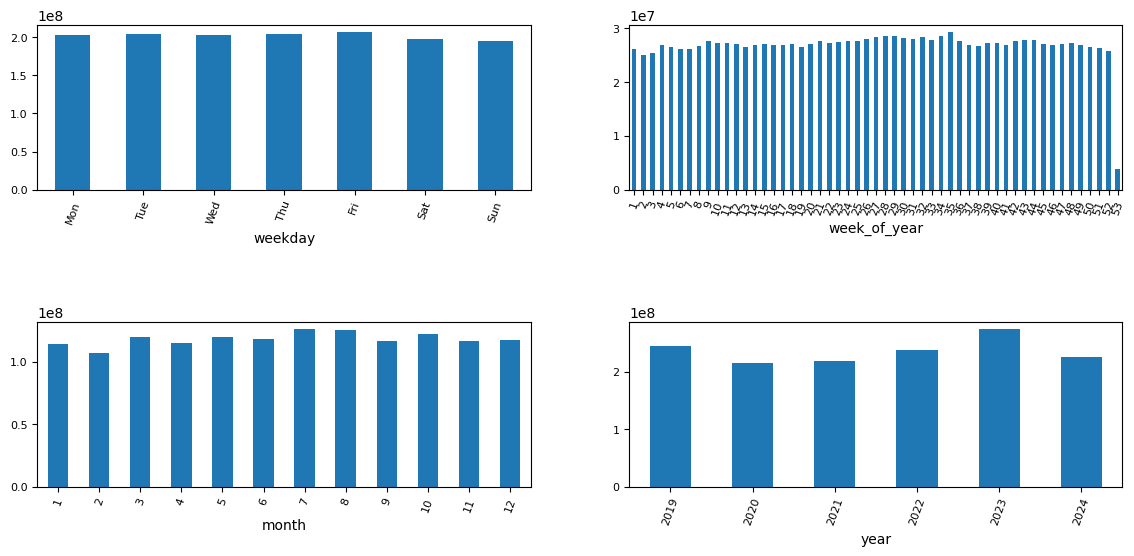

In [24]:
#Create summary plots over weekdays, week of year, months and years
import matplotlib.pyplot as plt

timeMetrics = ['weekday','week_of_year', 'month', 'year']
weekday_map= {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}

fig, axs = plt.subplots(2, 2, figsize = (14,6))
plt.subplots_adjust(hspace=0.8)    
for i, ax in enumerate(axs.flat):
    metric = timeMetrics[i]
    if metric == 'weekday':
        weekday_series= (
            footfall_19_24.groupby(['weekday'])['estimated_actual_footfall']
            .sum()
            .rename(index= weekday_map)
            .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']))
        weekday_series.plot.bar(ax=ax, rot=70, fontsize = 8) 
    else:
        footfall_19_24.groupby(metric)['estimated_actual_footfall'].sum().plot.bar(ax=ax, rot=70, fontsize = 8)   

Save the 3 cleaned datasets, ready for analysis:

In [25]:
footfall_clean.to_csv('footfall_cleaned')
footfall_19_24.to_csv('footfall_cleaned_19_24')
footfall_2025.to_csv('footfall_cleaned_2025')

In [26]:
footfall_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 278 entries, 2192 to 2469
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   datestamp                          278 non-null    datetime64[ns]
 1   estimated_actual_footfall          114 non-null    float64       
 2   estimated_actual_footfall_rolling  278 non-null    int64         
 3   year                               278 non-null    int64         
 4   month                              278 non-null    int64         
 5   monthday                           278 non-null    int64         
 6   weekday                            278 non-null    int64         
 7   week_of_year                       278 non-null    int64         
 8   Sin_weekday                        278 non-null    float64       
 9   Cos_weekday                        278 non-null    float64       
 10  Sin_monthday                       278 